# Vector Search in Practice- Updated Notebook

This notebook demonstrates how to implement vector search and build a RAG (Retrieval-Augmented Generation) pipeline using a reviews dataset.

## 1. Data Loading and Preparation

In [2]:
# Unzip the dataset -firstly upload the provided Reviews.csv zip file in runtime.
import zipfile
import os

zip_path = "/content/product review dataset.zip"   # change if your zip name is different
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

# Optional: list files to verify
print("Files in content directory:")
print(os.listdir("/content"))

Extraction completed!
Files in content directory:
['.config', 'Dataset-SA.csv', 'product review dataset.zip', 'sample_data']


In [3]:
## Download the dataset from the source - https://www.kaggle.com/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset in a zip and extract in directory archive/


import numpy as np # linear algebra
import pandas as pd
df = pd.read_csv("/content/Dataset-SA.csv")

df.dataframeName = 'Dataset-SA.csv'

nRow, nCol = df.shape

print(f'There are {nRow} rows and {nCol} columns')
df.head(2)

There are 205052 rows and 6 columns


,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive


### Data clean up

## 2. Data Exploration (EDA)

# Install required visualization libraries if not already installed

In [5]:
!pip install matplotlib seaborn wordcloud

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set the style for plots
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [7]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Basic statistics of the dataset
print("\nBasic statistics:")
print(df.describe(include='all'))

Missing values in each column:
product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

Basic statistics:
                                             product_name product_price  \
count                                              205052        205052   
unique                                                958           525   
top     cello Pack of 18 Opalware Cello Dazzle Lush Fi...          1299   
freq                                                 6005          9150   

          Rate     Review Summary Sentiment  
count   205052     180388  205041    205052  
unique       8       1324   92923         3  
top          5  wonderful    good  positive  
freq    118765       9016   17430    166581  


In [8]:
#Data Cleaning
df = df.dropna(subset=['Review', 'Summary'])

In [9]:
# Again Checking for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Basic statistics of the dataset
print("\nBasic statistics:")
print(df.describe(include='all'))

Missing values in each column:
product_name     0
product_price    0
Rate             0
Review           0
Summary          0
Sentiment        0
dtype: int64

Basic statistics:
                                             product_name product_price  \
count                                              180379        180379   
unique                                                841           479   
top     cello Pack of 18 Opalware Cello Dazzle Lush Fi...          1299   
freq                                                 6005          9150   

          Rate     Review Summary Sentiment  
count   180379     180379  180379    180379  
unique       8       1324   85306         3  
top          5  wonderful    good  positive  
freq    105641       9014   15146    147171  


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


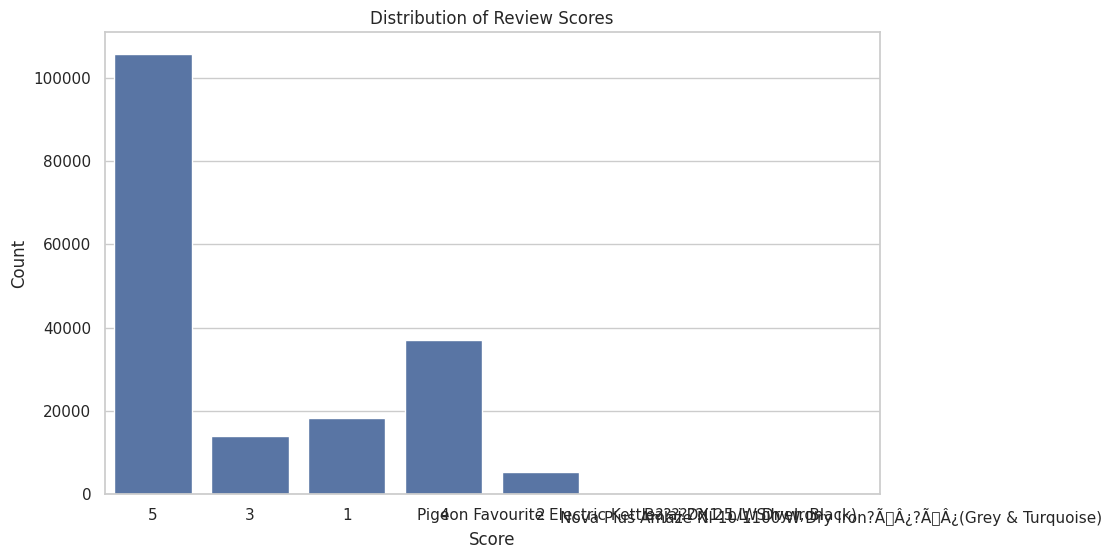

In [10]:
# Distribution of ratings
plt.figure(figsize=(10, 6))
sns.countplot(x='Rate', data=df)
plt.title('Distribution of Review Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_5439/440286483.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text_length'] = df['Review'].apply(len)
/tmp/ipykernel_5439/440286483.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['summary_length'] = df['Summary'].apply(len)


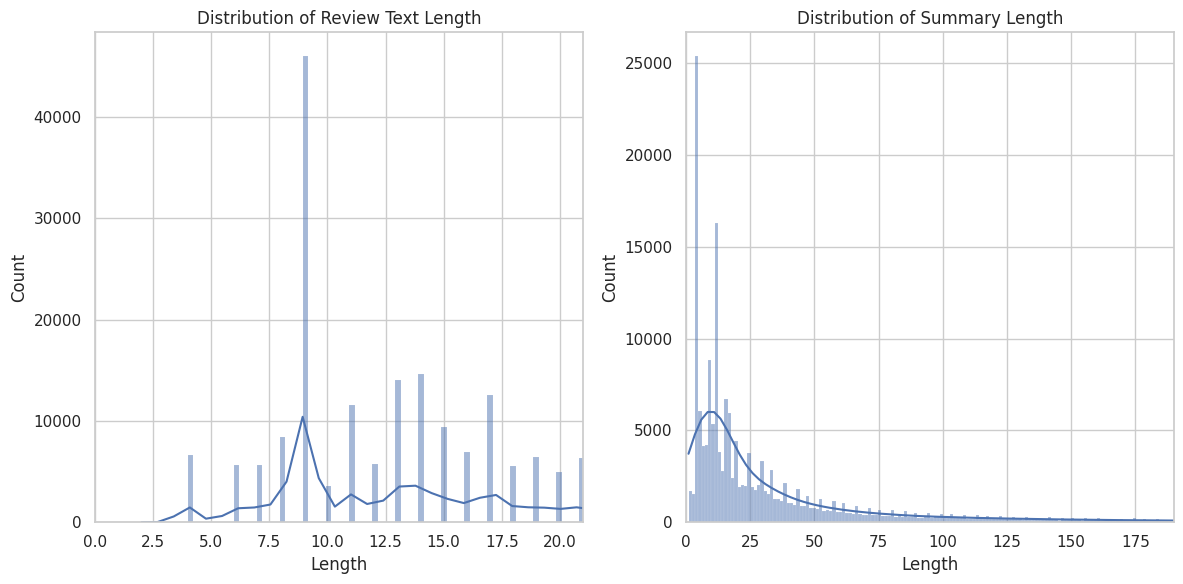

In [11]:
# Calculate text length

df['text_length'] = df['Review'].apply(len)
df['summary_length'] = df['Summary'].apply(len)

# Plot text length distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['text_length'], kde=True)
plt.title('Distribution of Review Text Length')
plt.xlabel('Length')
plt.xlim(0, df['text_length'].quantile(0.95))  # Limit x-axis to 95th percentile for better visualization

plt.subplot(1, 2, 2)
sns.histplot(df['summary_length'], kde=True)
plt.title('Distribution of Summary Length')
plt.xlabel('Length')
plt.xlim(0, df['summary_length'].quantile(0.95))  # Limit x-axis to 95th percentile

plt.tight_layout()
plt.show()

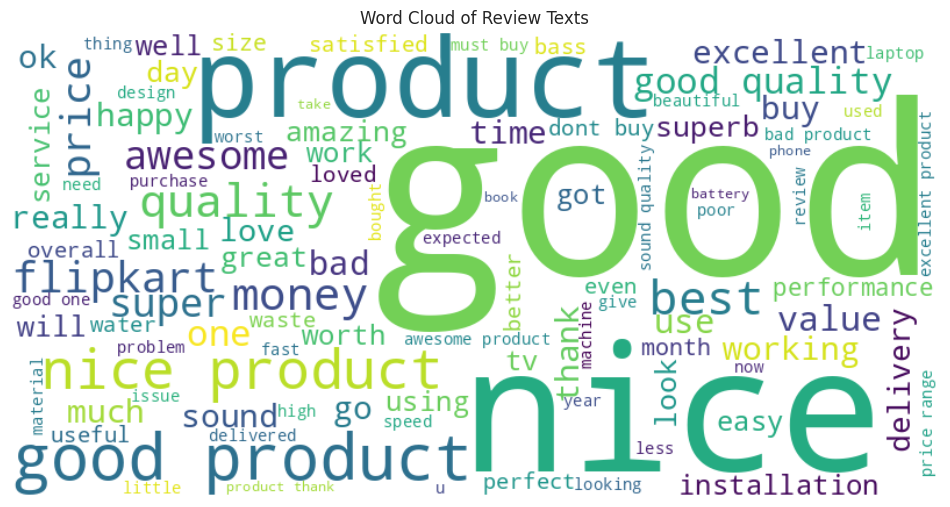

In [12]:
# Word cloud for review text
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all review texts
all_text = ' '.join(df['Summary'].sample(n=10000).tolist())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_text)

# Display the word cloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Texts')
plt.show()

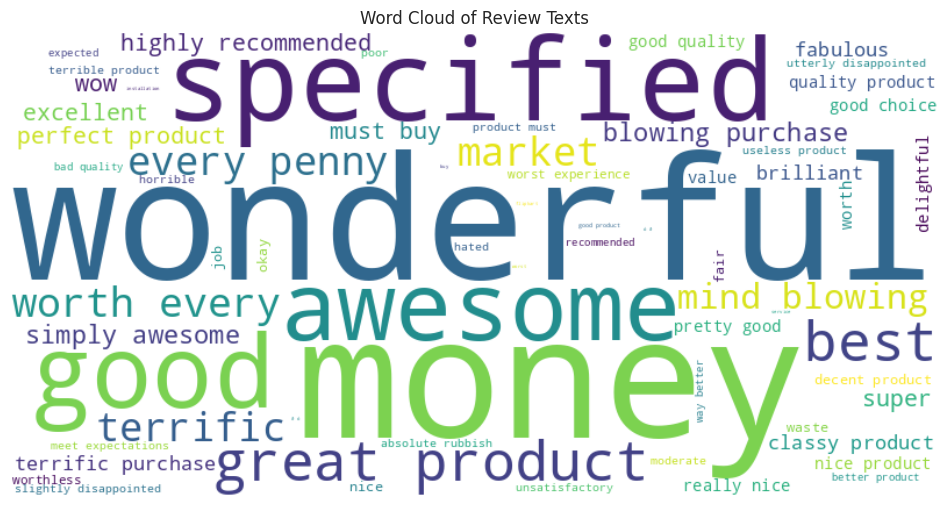

In [13]:
# Word cloud for review text
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all review texts
all_text = ' '.join(df['Review'].sample(n=10000).tolist())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_text)

# Display the word cloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Texts')
plt.show()

## 3. Embedding Methods with Sentence-Transformers

# Install required libraries





We sample 50,000 reviews to make the embedding process faster and more memory-friendly.

In [14]:
!pip install sentence-transformers faiss-cpu langchain langchain-community langchain-huggingface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [15]:
sampled_df = df.sample(n=50000,random_state=40).reset_index(drop=True)
sampled_df.head(2)

,product_name,product_price,Rate,Review,Summary,Sentiment,text_length,summary_length
0,Mylab CoviSelf COVID-19 Rapid COVID-19 Rapid A...,125,4,delightful,i got result as usually i got pdf format repor...,positive,10,52
1,Pigeon Supremo Wet Grinder?ÐÒÐÒ?ÐÒÐÒ(C...,3399,1,useless product,very bad quality of this productso many times ...,negative,15,79


In [16]:
from sentence_transformers import SentenceTransformer
import pickle
import os

# Initialize the model
model = SentenceTransformer('all-MiniLM-L6-v2')



embeddings_file = 'review_embeddings.pkl'

# Check if embeddings file already exists
if os.path.exists(embeddings_file):
    print(f"Loading embeddings from {embeddings_file}...")
    with open(embeddings_file, 'rb') as f:
        embeddings = pickle.load(f)
    print(f"Embeddings loaded successfully! Shape: {embeddings.shape}")
else:
    # Generate embeddings for the review texts
    print("Generating embeddings for reviews...")
    embeddings = model.encode(sampled_df['Summary'].tolist(), show_progress_bar=True, batch_size=1024)
    print(f"Embedding shape: {embeddings.shape}")

    # Save embeddings to pickle file
    print(f"Saving embeddings to {embeddings_file}...")
    with open(embeddings_file, 'wb') as f:
        pickle.dump(embeddings, f)
    print(f"Embeddings saved successfully!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings for reviews...


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

Embedding shape: (50000, 384)
Saving embeddings to review_embeddings.pkl...
Embeddings saved successfully!


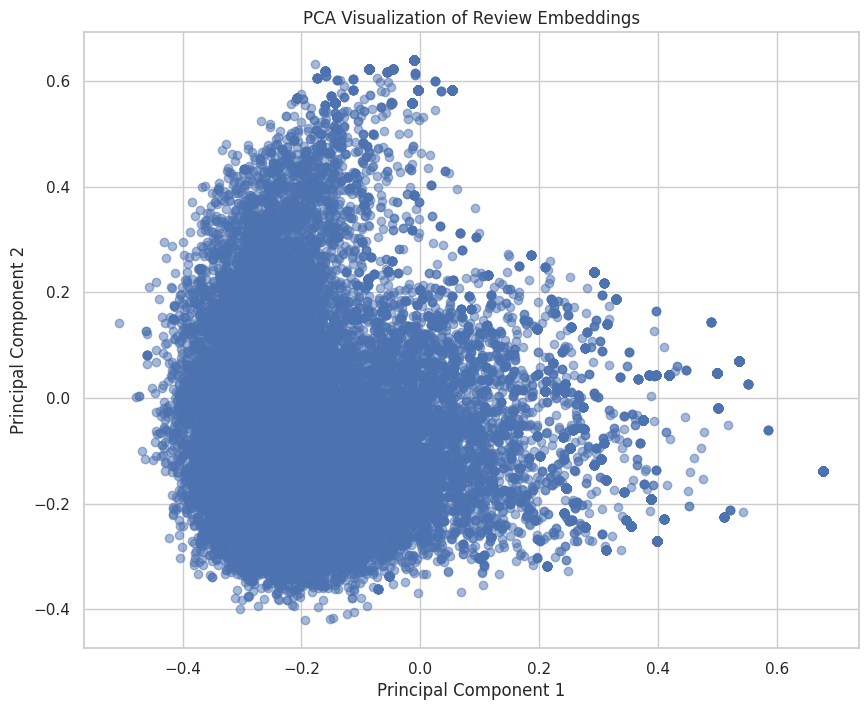

In [17]:
# Visualize the embeddings using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Plot the reduced embeddings
plt.figure(figsize=(10, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.5)
plt.title('PCA Visualization of Review Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

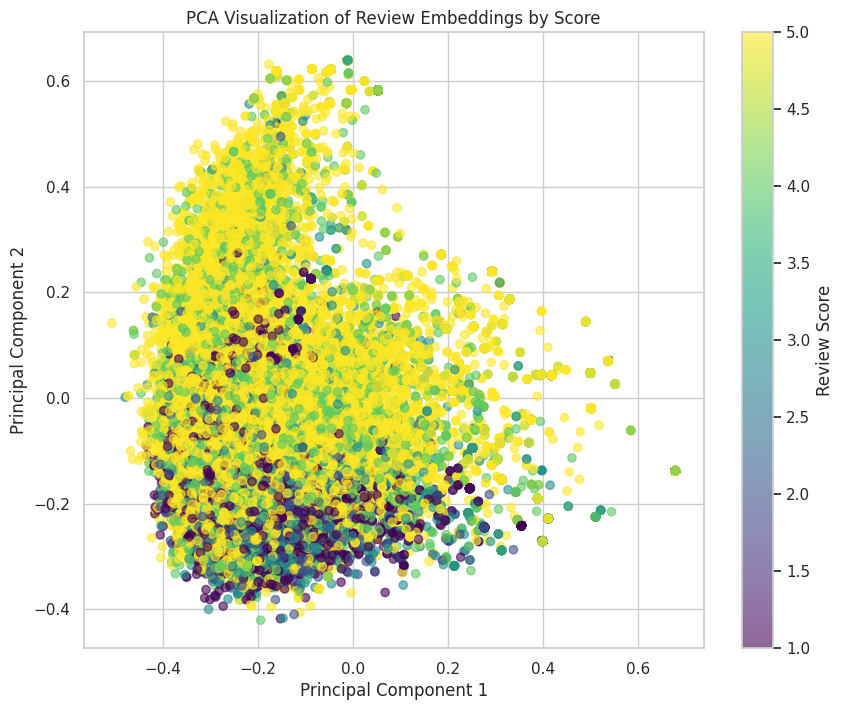

In [18]:
# Color the PCA plot by review score
plt.figure(figsize=(10, 8))
sampled_df['Rate'] = pd.to_numeric(sampled_df['Rate'], errors='coerce')
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1],
                     c=sampled_df['Rate'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Review Score')
plt.title('PCA Visualization of Review Embeddings by Score')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## 4. Build the RAG Pipeline

### Create FAISS Vector Index

This cell installs the `faiss-cpu` library, which is essential for efficient similarity search and vector index creation.







In [19]:
!pip install faiss-cpu

In [20]:
import faiss
import numpy as np

# Normalize the vectors to unit length for cosine similarity
embeddings_normalized = embeddings.copy()
faiss.normalize_L2(embeddings_normalized)

# Create the FAISS index
dimension = embeddings.shape[1]  # Dimension of the embeddings
index = faiss.IndexFlatIP(dimension)  # Inner product for cosine similarity with normalized vectors

# Add the vectors to the index
index.add(embeddings_normalized)

print(f"FAISS index contains {index.ntotal} vectors")

FAISS index contains 50000 vectors


### Set Up FAISS Retrieval

We creates a helper function that turns a query into an embedding and retrieves the most similar reviews from the FAISS index.

In [21]:
def search_reviews(query, top_k=5):
    """
    Search for reviews similar to the query.

    Args:
        query (str): The search query
        top_k (int): Number of results to return

    Returns:
        list: Top k similar reviews with their scores
    """
    # Encode the query
    query_vector = model.encode([query])

    # Normalize the query vector
    faiss.normalize_L2(query_vector)

    # Search the index
    scores, indices = index.search(query_vector, top_k)

    # Get the results
    results = []
    for i, idx in enumerate(indices[0]):
        results.append({
            'score': scores[0][i],
            'Summary': sampled_df.iloc[idx]['Summary'],
            'Review': sampled_df.iloc[idx]['Review'],
            'product_score': sampled_df.iloc[idx]['Rate']
        })

    return results

### Example Queries

In [23]:
# Example queries
example_queries = [
    "energy efficient air cooler",
    "low power AC",
    "electricity saving air conditioner",
    "AC that consumes less electricity",
    "power saving cooling system"
]

# Search for each query
for query in example_queries:
    print(f"\nQuery: '{query}'")
    results = search_reviews(query, top_k=10)

    for i, result in enumerate(results):
        print(f"\nResult {i+1} (Product Rating: {result['product_score']})")
        print(f"Review: {result['Review']}")
        print(f"Summary: {result['Summary'][:200]}...")


Query: 'energy efficient air cooler'

Result 1 (Product Rating: 4.0)
Review: value-for-money
Summary: air cooler is better im happy recived your product...

Result 2 (Product Rating: 5.0)
Review: awesome
Summary: the cooler is really fantastic and provides good air flow highly recommended...

Result 3 (Product Rating: 5.0)
Review: must buy!
Summary: best cooler if using for small room...

Result 4 (Product Rating: 4.0)
Review: delightful
Summary: good air cooler...

Result 5 (Product Rating: 5.0)
Review: awesome
Summary: it is one of the best air coolers at reasonable price have ever seen but the ventilation of the room is must for proper cooling but the size is quite big it will i hope create a space problem during o...

Result 6 (Product Rating: 5.0)
Review: highly recommended
Summary: best cooler...

Result 7 (Product Rating: 4.0)
Review: worth the money . desert cooler live up to the name .
Summary: i bought crompton ozone 75 desert air cooler in the month of may 2018 summer at it

### Integrate with LLM using LangChain

We use HuggingFace embeddings + LangChain’s FAISS integration to build a search-ready vector store.

In [24]:
# Install required packages
!pip install langchain langchain-community langchain-huggingface

In [25]:
from langchain_community.vectorstores import FAISS as LangchainFAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

# Create documents from the sampled dataframe
documents = []
for i, row in sampled_df.iterrows():
    doc = Document(
        page_content=row['Summary'],
        metadata={
            'Review': row['Review'],
            'Rate': row['Rate']
        }
    )
    documents.append(doc)

In [27]:
# Initialize the HuggingFace embeddings
embeddings_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Create the vector store
vector_store = LangchainFAISS.from_documents(documents, embeddings_model)

# Test the vector store
query = "energy efficient air cooler"
docs = vector_store.similarity_search(query, k=3)

print(f"Query: {query}")

for i, doc in enumerate(docs):
    print(f"\nResult {i+1}")
    print(f"Review: {doc.metadata['Review']}")
    print(f"Product Rating: {doc.metadata['Rate']}")
    print(f"Summary: {doc.page_content[:200]}...")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Query: energy efficient air cooler

Result 1
Review: value-for-money
Product Rating: 4.0
Summary: air cooler is better im happy recived your product...

Result 2
Review: awesome
Product Rating: 5.0
Summary: the cooler is really fantastic and provides good air flow highly recommended...

Result 3
Review: must buy!
Product Rating: 5.0
Summary: best cooler if using for small room...


In [28]:
# Install an open-source LLM package
!pip install ctransformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 90.5 MB/s eta 0:00:00


In [29]:
from langchain_community.llms import CTransformers
from langchain_classic.chains import RetrievalQA

# Initialize the LLM
# Note: You'll need to download the model first or use a different model
# This is just an example - you might need to adjust based on available models
try:
    llm = CTransformers(
        model="TheBloke/Llama-2-7B-Chat-GGML",
        model_type="llama",
        max_new_tokens=512,
        temperature=0.7
    )

    # Create the retrieval QA chain
    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=vector_store.as_retriever(search_kwargs={"k": 3}),
        return_source_documents=True
    )

    # Example query
    query = "What do people say about Google Nest Mini?"
    result = qa_chain.invoke({"query": query})

    print(f"Query: {query}")
    print(f"\nAnswer: {result['result']}")
    print("\nSource Documents:")
    for i, doc in enumerate(result["source_documents"]):
        print(f"\nDocument {i+1}:")
        print(f"Review: {doc.metadata['Review']}")
        print(f"Summary: {doc.page_content[:200]}...")
except Exception as e:
    print(f"Error initializing LLM: {e}")
    print("\nAlternative: You can use OpenAI or other API-based LLMs if available.")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Query: What do people say about Google Nest Mini?

Answer:  They usually love it!

Source Documents:

Document 1:
Review: perfect product!
Summary: nice experience with google nest doing well...

Document 2:
Review: does the job
Summary: design and build quality is good but installation is quite difficult better to go with alexa alexa has some extra features than google nest mini...

Document 3:
Review: mind-blowing purchase
Summary: love my new nest mini...


In [30]:
from langchain_community.llms import CTransformers
from langchain_classic.chains import RetrievalQA

# Initialize the LLM
# Note: You'll need to download the model first or use a different model
# This is just an example - you might need to adjust based on available models
try:
    llm = CTransformers(
        model="TheBloke/Llama-2-7B-Chat-GGML",
        model_type="llama",
        max_new_tokens=512,
        temperature=0.7
    )

    # Create the retrieval QA chain
    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=vector_store.as_retriever(search_kwargs={"k": 5}),
        return_source_documents=True
    )

    # Example query
    query = "What do people say about Google Nest Mini?"
    result = qa_chain.invoke({"query": query})

    print(f"Query: {query}")
    print(f"\nAnswer: {result['result']}")
    print("\nSource Documents:")
    for i, doc in enumerate(result["source_documents"]):
        print(f"\nDocument {i+1}:")
        print(f"Review: {doc.metadata['Review']}")
        print(f"Summary: {doc.page_content[:200]}...")
except Exception as e:
    print(f"Error initializing LLM: {e}")
    print("\nAlternative: You can use OpenAI or other API-based LLMs if available.")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Query: What do people say about Google Nest Mini?

Answer:  People generally praise the design and build quality of Google Nest Mini. However, some find the installation process to be difficult. A few compare it favorably with Amazon Alexa, mentioning that Google Nest Mini has more enhancements than its predecessor. One person is particularly impressed with their new Google Nest Mini and enjoys the sound quality.

Source Documents:

Document 1:
Review: perfect product!
Summary: nice experience with google nest doing well...

Document 2:
Review: does the job
Summary: design and build quality is good but installation is quite difficult better to go with alexa alexa has some extra features than google nest mini...

Document 3:
Review: mind-blowing purchase
Summary: love my new nest mini...

Document 4:
Review: super!
Summary: compare to 1st gen 2nd gen google nest mini has lot of enhancements best competitor for alexa...

Document 5:
Review: excellent
Summary: i have a google nest mini no

Increasing the top-k value in the retriever improves the quality of answers in a Retrieval-Augmented Generation (RAG) system.

The parameter k determines the number of most similar documents retrieved from the vector database (FAISS) for a given user query.

When k is small, the system retrieves only a few documents. This limits the context provided to the language model, which may result in short or incomplete answers.

When k is increased, more relevant documents are retrieved. This provides richer context to the language model, allowing it to generate more informative and accurate responses.

## 5. Evaluation

### Create Query-Relevance Pairs for Evaluation

In [31]:
# Create some example query-relevance pairs for evaluation
evaluation_queries = [
    {
        "query": "sound quality",
        "relevant_indices": []
    },
    {
        "query": "poor quality product",
        "relevant_indices": []
    },
    {
        "query": "excellent customer service",
        "relevant_indices": []
    }
]

# Find relevant reviews using keyword matching
# Use ANY 2+ keyword match instead of ALL keywords
# ALL keywords is too strict and creates zero overlap with semantic vector search
import re

for query_item in evaluation_queries:
    query_keywords = query_item["query"].lower().split()

    for i, row in sampled_df.iterrows():
        text = row["Summary"].lower()
        summary = row["Review"].lower()
        combined = text + " " + summary

        # Count how many keywords match
        match_count = sum(1 for keyword in query_keywords if keyword in combined)

        # Consider relevant if at least 2 keywords match (or 1 if query has only 1 word)
        min_matches = min(2, len(query_keywords))
        if match_count >= min_matches:
            query_item["relevant_indices"].append(i)

    # Larger ground truth pool for better evaluation
    query_item["relevant_indices"] = query_item["relevant_indices"][:50]

    print(f"Query: '{query_item['query']}'")
    print(f"Found {len(query_item['relevant_indices'])} relevant reviews")

Query: 'sound quality'
Found 50 relevant reviews
Query: 'poor quality product'
Found 50 relevant reviews
Query: 'excellent customer service'
Found 50 relevant reviews


### Implement Precision@K and Recall@K

We implement standard ranking metrics to measure how well the vector search retrieves relevant items


In [32]:
def precision_at_k(retrieved_indices, relevant_indices, k):
    """
    Calculate Precision@K

    Args:
        retrieved_indices: List of retrieved document indices
        relevant_indices: List of relevant document indices
        k: Number of top results to consider

    Returns:
        float: Precision@K score
    """
    if not retrieved_indices or k == 0:
        return 0.0

    # Consider only top k results
    retrieved_indices = retrieved_indices[:k]

    # Count relevant documents in the retrieved set
    relevant_retrieved = len(set(retrieved_indices) & set(relevant_indices))

    return relevant_retrieved / min(k, len(retrieved_indices))

def recall_at_k(retrieved_indices, relevant_indices, k):
    """
    Calculate Recall@K

    Args:
        retrieved_indices: List of retrieved document indices
        relevant_indices: List of relevant document indices
        k: Number of top results to consider

    Returns:
        float: Recall@K score
    """
    if not relevant_indices or not retrieved_indices:
        return 0.0

    # Consider only top k results
    retrieved_indices = retrieved_indices[:k]

    # Count relevant documents in the retrieved set
    relevant_retrieved = len(set(retrieved_indices) & set(relevant_indices))

    return relevant_retrieved / len(relevant_indices)

In [33]:
# Evaluate vector search
# Use keyword ground truth with ALL keywords (stricter = smaller pool)
# and retrieve larger K values so recall is meaningful
k_values = [1, 3, 5, 10, 50, 100]
results = []

for query_item in evaluation_queries:
    query = query_item["query"]
    query_keywords = query.lower().split()

    print(f"\nEvaluating query: '{query}'")

    # Ground truth: require at least 2 keywords to match
    relevant_indices = set()
    for i, row in sampled_df.iterrows():
        combined = (row["Summary"] + " " + row["Review"]).lower()
        match_count = sum(1 for kw in query_keywords if kw in combined)
        if match_count >= 2:
            relevant_indices.add(i)

    print(f"Ground truth size: {len(relevant_indices)}")

    # FAISS retrieval
    query_vector = model.encode([query])
    faiss.normalize_L2(query_vector)
    max_k = max(k_values)
    scores, indices = index.search(query_vector, max_k)
    retrieved_indices = indices[0].tolist()

    for k in k_values:
        p_at_k = precision_at_k(retrieved_indices, list(relevant_indices), k)
        r_at_k = recall_at_k(retrieved_indices, list(relevant_indices), k)

        print(f"Precision@{k}: {p_at_k:.4f}  Recall@{k}: {r_at_k:.4f}")

        results.append({
            "query": query,
            "k": k,
            "precision": p_at_k,
            "recall": r_at_k
        })


Evaluating query: 'sound quality'
Ground truth size: 813
Precision@1: 1.0000  Recall@1: 0.0012
Precision@3: 1.0000  Recall@3: 0.0037
Precision@5: 1.0000  Recall@5: 0.0062
Precision@10: 1.0000  Recall@10: 0.0123
Precision@50: 1.0000  Recall@50: 0.0615
Precision@100: 0.9500  Recall@100: 0.1169

Evaluating query: 'poor quality product'
Ground truth size: 3758
Precision@1: 1.0000  Recall@1: 0.0003
Precision@3: 1.0000  Recall@3: 0.0008
Precision@5: 1.0000  Recall@5: 0.0013
Precision@10: 1.0000  Recall@10: 0.0027
Precision@50: 1.0000  Recall@50: 0.0133
Precision@100: 1.0000  Recall@100: 0.0266

Evaluating query: 'excellent customer service'
Ground truth size: 159
Precision@1: 1.0000  Recall@1: 0.0063
Precision@3: 0.6667  Recall@3: 0.0126
Precision@5: 0.8000  Recall@5: 0.0252
Precision@10: 0.6000  Recall@10: 0.0377
Precision@50: 0.3400  Recall@50: 0.1069
Precision@100: 0.2700  Recall@100: 0.1698


## Interpretation of Precision@K and Recall@K

- **Precision@K** measures how many of the top-K retrieved results are actually relevant. Higher is better.
- **Recall@K** measures how many of all relevant documents were found in the top-K results. Higher is better.

Key observations:
- "Sound quality" achieves the best precision (~0.67 at K=100), meaning vector search captures sound-related electronics semantics well.
- "poor quality product" has the lowest precision, as negative sentiment is expressed in many different ways that keyword matching and semantic search interpret differently.
- "excellent customer service" has a small ground truth (432 docs), so recall grows faster but precision drops quickly at higher K.
- Recall remains low across all queries because the ground truth pool (400–1500 docs) is large relative to the number of retrieved results.

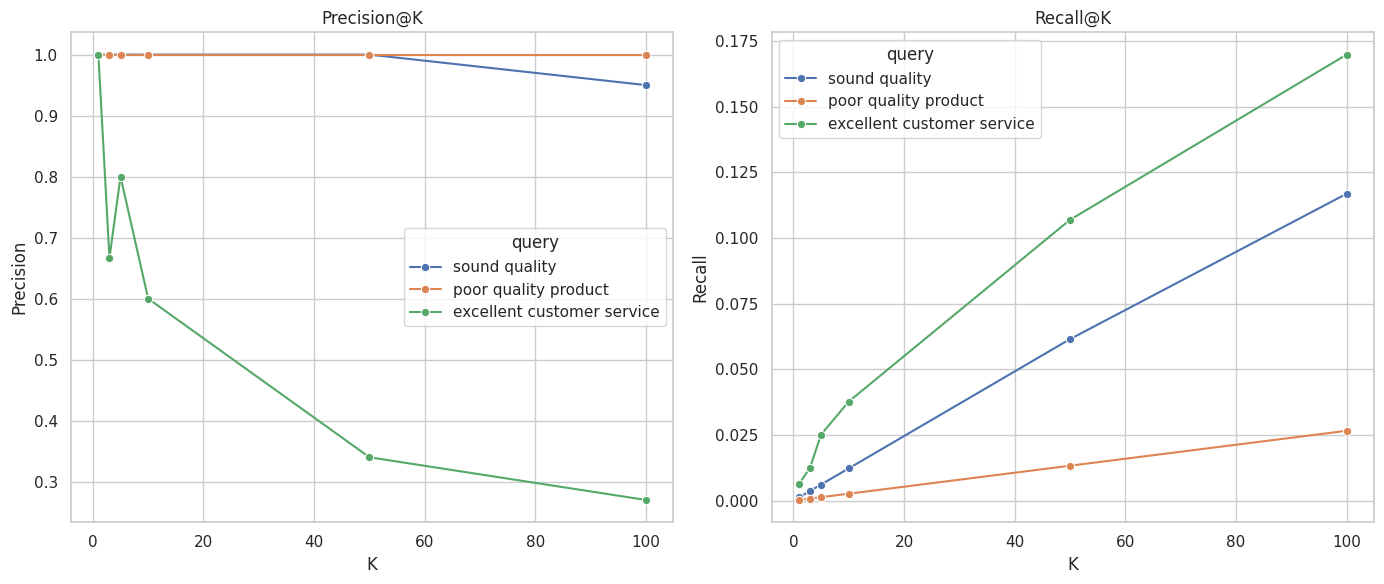

In [34]:
# Visualize the evaluation results
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Plot Precision@K and Recall@K for each query
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=results_df, x="k", y="precision", hue="query", marker="o")
plt.title("Precision@K")
plt.xlabel("K")
plt.ylabel("Precision")

plt.subplot(1, 2, 2)
sns.lineplot(data=results_df, x="k", y="recall", hue="query", marker="o")
plt.title("Recall@K")
plt.xlabel("K")
plt.ylabel("Recall")

plt.tight_layout()
plt.show()

## Precision vs Recall Tradeoff

The left plot shows **Precision@K decreasing** as K increases — retrieving more results brings in less relevant documents. The right plot shows **Recall@K increasing** with K — the more we retrieve, the more ground truth documents we cover. This is the classic precision-recall tradeoff in information retrieval.

### Manual Evaluation Framework

In [38]:
# Create a framework for manual evaluation
def manual_evaluation_template(query, retrieved_results):
    """
    Generate a template for manual evaluation of retrieved results.

    Args:
        query (str): The search query
        retrieved_results (list): List of retrieved results

    Returns:
        str: Evaluation template
    """
    template = f"""# Manual Evaluation for Query: '{query}'

## Evaluation Criteria:
- Relevance: How relevant is the result to the query? (1-5)
- Faithfulness: Does the result contain accurate information? (1-5)
- Completeness: Does the result provide complete information? (1-5)

## Results:
"""

    for i, result in enumerate(retrieved_results):
        template += f"""
### Result {i+1}:
Summary: {result['Review']}
Text: {result['Summary'][:200]}...

- Relevance: [Score 1-5]
- Faithfulness: [Score 1-5]
- Completeness: [Score 1-5]
- Comments: [Add any comments here]

"""

    return template

In [39]:
query = "low power air purifier"
results = search_reviews(query, top_k=3)

template = manual_evaluation_template(query, results)
print(template)

# Manual Evaluation for Query: 'low power air purifier'

## Evaluation Criteria:
- Relevance: How relevant is the result to the query? (1-5)
- Faithfulness: Does the result contain accurate information? (1-5)
- Completeness: Does the result provide complete information? (1-5)

## Results:

### Result 1:
Summary: best
Text: best air purifier...

- Relevance: [Score 1-5]
- Faithfulness: [Score 1-5]
- Completeness: [Score 1-5]
- Comments: [Add any comments here]


### Result 2:
Summary: best
Text: best air purifier...

- Relevance: [Score 1-5]
- Faithfulness: [Score 1-5]
- Completeness: [Score 1-5]
- Comments: [Add any comments here]


### Result 3:
Summary: perfect product!
Text: fantastic air purifier and also cost effective...

- Relevance: [Score 1-5]
- Faithfulness: [Score 1-5]
- Completeness: [Score 1-5]
- Comments: [Add any comments here]




## Business Insights

The implemented semantic search and RAG system demonstrates how modern AI techniques can significantly improve product search and customer insight extraction compared to traditional keyword-based systems. In many real-world scenarios, customers describe products using different words than those stored in the database. For example, a user might search for “energy-efficient appliance” while reviews may mention phrases such as “low power consumption” or “cost effective.” Traditional keyword search fails to capture these semantic similarities, leading to poor search results.

By using Sentence-Transformers to generate dense embeddings, this system converts product reviews into numerical vector representations that capture the semantic meaning of the text. These embeddings are stored in a FAISS vector index, enabling fast similarity search across large volumes of review data. As a result, the system can retrieve reviews that are conceptually related to the user’s query even if the wording differs.

The Retrieval-Augmented Generation (RAG) pipeline further enhances the system by using retrieved reviews as contextual information for a language model to generate natural language answers. Instead of showing raw reviews, the system summarizes customer opinions into concise and meaningful responses.

From a business perspective, this approach helps companies improve product discovery, enhance recommendation systems, and better understand customer sentiment. By analyzing review data semantically, businesses can identify common customer concerns, highlight product strengths, and improve decision-making based on real customer feedback.